### Artifacts of circular convolution in the NFT and Balloon-Windkessel models

The neural field theory (NFT) wave model (`waves.sim_nft_waves()`) defines simulated activity as a
convolution of the NFT transfer function with an external spatiotemporal input, and offers two
implementations: the ODE method sequentially solves for each timepoint of output activity using
Runge-Kutta approximation, whereas the Fourier method (default) applies a faster, analytical
solution by leveraging the *Convolution Theorem* (convolution in the temporal domain is equivalent
to multiplication in the frequency domain).

However, unlike *linear convolution* (sliding one
function over the other in the temporal domain), applying forward and inverse Fourier transforms
treats the timeseries as once cycle of a periodic signal, thereby making frequency-domain
multiplication *circular convolution*. This means that the last timepoint is treated as adjacent to
the first timepoint, leading the transfer function to propagate input across this boundary and
contaminate early outputs. 

To prevent these wrap-around
artifacts and better approximate a linear convolution, input timeseries are commonly padded with
zeros. Placed at the very start or end of the array, these timepoints serve as a buffer to absorb
wrap-around, and are discarded following inverse Fourier transform back to the temporal domain.

The number of zeros to add depends on the impulse response of the transfer function--specifically, how
far in time an impulse is propagated. Many transfer functions from signal processing have a *finite
impulse response*, meaning that there exists some timepoint $t_1=t_0+k$ after which the input at $t_0$ has
no influence on the output at $t_1$. Consider a $k$-point simple moving average: the values $k+1$
timepoints away from the current timepoint do not influence the output. In this case, padding with
$k$ zeros will guarantee no wrap-around, equating the circular convolution with a linear
convolution.

However, transfer functions for many physical systems often have an *infinite impulse response*,
meaning that the transfer function propagates input to all timepoints. Consider convolution with an
exponential decay kernel $e^{-\alpha t}$: input at $t_0$ will influence $t_1$ for all $k$, but less
so for larger $k$. In this case, we must decide a tolerance for wrap-around, then solve $e^{-\alpha
t} < tol$ for $t$, representing the padding time needed for an impulse to decay to below the
tolerance. This lets us explicitly control the tradeoff between simulation accuracy ($tol = 0$,
infinite padding) and computational efficiency ($tol = 1$, no padding). For more information, see
*Numerical Recipes - The Art of Scientific Computing (Third Edition)*, Chapter 13.1.1.

Per Pang *et al.* (2023; Supplement S8), the NFT wave model applies a transfer function to each
geometric eigenmode's input frequency spectrum. The $j^{th} $ mode has a transfer function of:
 
$$H_j(\omega)=\frac{\gamma_s^2}{-\omega^2-2i\omega\gamma_s+\gamma_s^2(1+r_s^2\lambda_j)}$$

Briefly, we can find the temporal decay by solving for the roots of the denominator in the Laplace
domain. We apply the Laplace transform using the $s=i\omega$ convention, followed by the quadratic formula:

$$ H_j(s)=\frac{\gamma_s^2}{s^2-2s\gamma_s+\gamma_s^2(1+r_s^2\lambda_j)}$$

$$ s^2-2s\gamma_s+\gamma_s^2(1+r_s^2\lambda_j)=0 $$
$$ s=\frac{-(2\gamma_s)\pm\sqrt{(2\gamma_s)^2-4(1)(\gamma_s^2(1+r_s^2\lambda_j))}}{2(1)} $$
$$ =-\gamma_s\pm i\gamma_s r\sqrt{\lambda_j} $$

Applying the inverse Laplace transform to this complex conjugate pair yields temporal terms of

$$e^{st}=e^{(-\gamma_s\pm i\gamma_s r\sqrt{\lambda_j})t}$$
$$=e^{-\gamma_s t}e^{(\pm i\gamma_s r\sqrt{\lambda_j})t}$$
$$=e^{-\gamma_s t}(\cos(\gamma_s r\sqrt{\lambda_j}t)\pm i \sin(\gamma_s r\sqrt{\lambda_j}t))$$

As seen above, the oscillatory terms are subject to an exponential decay envelope, meaning we can
apply the padding approach from our $e^{-\alpha t}$ example.

Similarly, the Balloon-Windkessel model can be understood in the frequency-domain, with its transfer
function of:

$$H(\omega)=V_0\frac{
    \alpha(k_2+k_3)(1-i\tau\omega)-(k_1+k_2)(\alpha+\beta-1-i\tau\alpha\beta\omega)
    }{
        (1-i\tau\omega)(1-i\tau\alpha\omega)(-(\omega+i\kappa/2)^2+w_f^2)
        },$$
$$\beta=\rho+(1-\rho)\ln(1-\rho)/\rho$$

Again, using the Laplace transform (except here with the alternative convention $s=-i\omega$)
reveals *three* exponential poles:

$$H(s)=V_0\frac{
    \alpha(k_2+k_3)(1+\tau s)-(k_1+k_2)(\alpha+\beta-1+\tau\alpha\beta s)
    }{(1+\tau s)(1+\tau\alpha s)((s+\kappa/2)^2+w_f^2)}$$
$$(1+\tau s)(1+\tau\alpha s)((s+\kappa/2)^2+w_f^2)=0$$
$$s=-\frac{1}{\tau},-\frac{1}{\tau \alpha},-\frac{\kappa}{2}\pm iw_f$$
$$e^{st}=e^{-\frac{t}{\tau}}, e^{-\frac{t}{\tau \alpha}}, e^{(-\frac{\kappa}{2}\pm iw_f)t}$$

As with the wave model, we can ignore the imaginary oscillatory component of the third pole to
retain only the decay envelope. For the purposes of zero-padding, we are interested in the slowest
of these decays, found via $\min(frac{1}{\tau},frac{t}{\tau\alpha},\frac{\kappa}{2})$.

In [136]:
import matplotlib.pyplot as plt
import numpy as np

from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf
from neuromodes.stats import meanw

In [2]:
surf, medmask = fetch_example_surf(density='4k')
solver = EigenSolver(surf, medmask).solve(500)

In [86]:
nt = 100
dt = 1e-4
gamma = 116
ext_input = np.zeros((solver.n_verts, nt))
ext_input[:, 10] = 1.0

In [122]:
ode_mean = meanw(solver.sim_nft_waves(ext_input=ext_input, method='ode', dt=dt, gamma=gamma), solver.mass)
fourier_nt_mean = meanw(solver.sim_nft_waves(ext_input=ext_input, padding_tol='nt', method='fourier', dt=dt, gamma=gamma), solver.mass)
fourier_1e1_mean = meanw(solver.sim_nft_waves(ext_input=ext_input, padding_tol=1e-1, method='fourier', dt=dt, gamma=gamma), solver.mass)
fourier_1e2_mean = meanw(solver.sim_nft_waves(ext_input=ext_input, padding_tol=1e-2, method='fourier', dt=dt, gamma=gamma), solver.mass)
fourier_1e3_mean = meanw(solver.sim_nft_waves(ext_input=ext_input, padding_tol=1e-3, method='fourier', dt=dt, gamma=gamma), solver.mass)

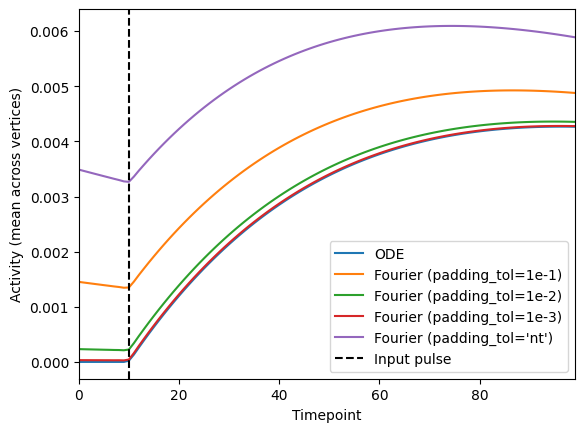

In [123]:
plt.plot(ode_mean, label='ODE')
plt.plot(fourier_1e1_mean, label='Fourier (padding_tol=1e-1)')
plt.plot(fourier_1e2_mean, label='Fourier (padding_tol=1e-2)')
plt.plot(fourier_1e3_mean, label='Fourier (padding_tol=1e-3)')
plt.plot(fourier_nt_mean, label="Fourier (padding_tol='nt')")
plt.axvline(x=10, color='k', linestyle='--', label='Input pulse')
plt.xlabel('Timepoint')
plt.ylabel('Activity (mean across vertices)')
plt.xlim(0, nt-1)
plt.legend()
plt.show()

In [132]:
seed = 0
ode = solver.sim_nft_waves(nt=nt, method='ode', dt=dt, gamma=gamma, seed=seed)

In [105]:
fourier_nt = solver.sim_nft_waves(nt=nt, padding_tol='nt', method='fourier', dt=dt, gamma=gamma, seed=seed)
fourier_1e1 = solver.sim_nft_waves(nt=nt, padding_tol=1e-1, method='fourier', dt=dt, gamma=gamma, seed=seed)
fourier_1e2 = solver.sim_nft_waves(nt=nt, padding_tol=1e-2, method='fourier', dt=dt, gamma=gamma, seed=seed)
fourier_1e3 = solver.sim_nft_waves(nt=nt, padding_tol=1e-3, method='fourier', dt=dt, gamma=gamma, seed=seed)

In [ ]:
mse_1e1 = meanw((ode - fourier_1e1)**2, solver.mass)
mse_1e2 = meanw((ode - fourier_1e2)**2, solver.mass)
mse_1e3 = meanw((ode - fourier_1e3)**2, solver.mass)
mse_nt = meanw((ode - fourier_nt)**2, solver.mass)

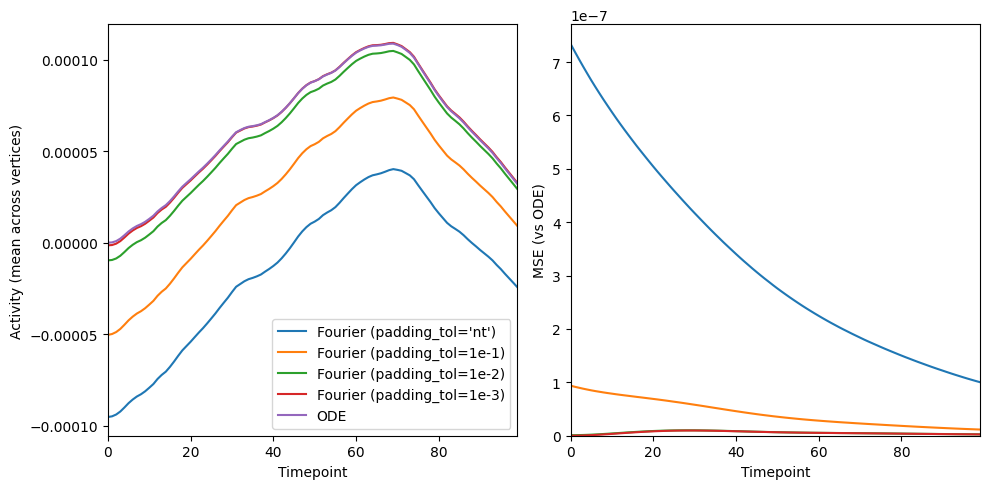

In [120]:
# above plots but as a single figure
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(meanw(fourier_nt, solver.mass), label="Fourier (padding_tol='nt')")
axs[0].plot(meanw(fourier_1e1, solver.mass), label='Fourier (padding_tol=1e-1)')
axs[0].plot(meanw(fourier_1e2, solver.mass), label='Fourier (padding_tol=1e-2)')
axs[0].plot(meanw(fourier_1e3, solver.mass), label='Fourier (padding_tol=1e-3)')
axs[0].plot(meanw(ode, solver.mass), label='ODE')
axs[0].set_xlabel('Timepoint')
axs[0].set_ylabel('Activity (mean across vertices)')
axs[0].set_xlim(0, nt-1)
axs[0].legend()
axs[1].plot(mse_nt)
axs[1].plot(mse_1e1)
axs[1].plot(mse_1e2)
axs[1].plot(mse_1e3)
axs[1].set_xlabel('Timepoint')
axs[1].set_ylabel('MSE (vs ODE)')
axs[1].set_xlim(0, nt-1)
axs[1].set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [133]:
bold_ode = solver.balloon_model(ode, dt=dt, method='ode')
bold_fourier_nt = solver.balloon_model(ode, dt=dt, padding_tol='nt')
bold_fourier_1e1 = solver.balloon_model(ode, dt=dt, padding_tol=1e-1)

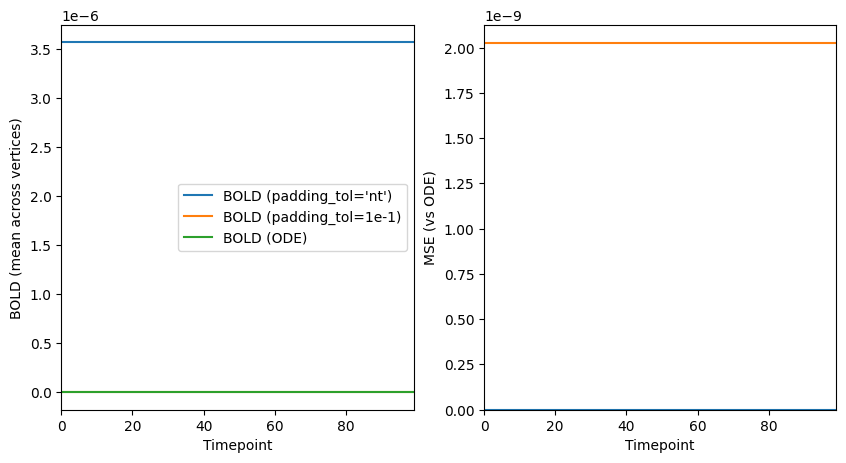

In [135]:
bold_mse_1e1 = meanw((bold_ode - bold_fourier_1e1)**2, solver.mass)
bold_mse_nt = meanw((bold_ode - bold_fourier_nt)**2, solver.mass)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(meanw(bold_fourier_nt, solver.mass), label="BOLD (padding_tol='nt')")
axs[0].plot(meanw(bold_fourier_1e1, solver.mass), label='BOLD (padding_tol=1e-1)')
axs[0].plot(meanw(bold_ode, solver.mass), label='BOLD (ODE)')
axs[0].set_xlabel('Timepoint')
axs[0].set_ylabel('BOLD (mean across vertices)')
axs[0].set_xlim(0, nt-1)
axs[0].legend()
axs[1].plot(bold_mse_1e1, label='MSE (padding_tol=1e-1)')
axs[1].plot(bold_mse_nt, label='MSE (padding_tol=\'nt\')')
axs[1].set_xlabel('Timepoint')
axs[1].set_ylabel('MSE (vs ODE)')
axs[1].set_xlim(0, nt-1)
axs[1].set_ylim(bottom=0)
plt.show()

In [ ]:
# TODO: show faster computation for large nt with padding_tol='nt' vs padding_tol=1e-5
# TODO: find better params for BOLD comparison (probably need to increase dt and nt)
# TODO: show superiority for all three balloon min decays